In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pyiga

import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy

In [2]:
kvs = [2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       2*(bspline.make_knots(2,0,1,2),),
       (bspline.make_knots(2,0,1,4),bspline.make_knots(2,0,1,2)),
       (bspline.make_knots(2,0,1,4),bspline.make_knots(2,0,1,2)),
       (bspline.make_knots(2,0,1,4),bspline.make_knots(2,0,1,2)),
       (bspline.make_knots(2,0,1,4),bspline.make_knots(2,0,1,2)),
        2*(bspline.make_knots(2,0,1,2),)
      ]
coeffs = [np.array([
    [0.655013, 4.33787],
    [0.57201,  4.41638],
    [0.406003, 4.57338],
    [0.323,    4.65188],
    [0.74825,  4.47773],
    [0.768051, 4.60196],
    [0.654814, 4.80896],
    [0.642669, 4.94824],
    [1.09147,  4.45694],
    [1.14567,  4.52524],
    [1.26381,  4.71249],
    [1.23196,  4.80322],
    [1.22621,  4.30336],
    [1.3193,   4.3995],
    [1.3855,   4.6321],
    [1.3586,   4.76841],
]),
np.array([
    [1.22621, 4.30336],
    [1.3193,  4.3995],
    [1.3855,  4.6321],
    [1.3586,  4.76841],
    [1.3941,  4.305],
    [1.45285, 4.4019],
    [1.49747, 4.61122],
    [1.48523, 4.73359],
    [1.6098,  4.2083],
    [1.64611, 4.31673],
    [1.74325, 4.52785],
    [1.79814, 4.63854],
    [1.73769, 4.10995],
    [1.7528,  4.2421],
    [1.8429,  4.4764],
    [1.91802, 4.59858],
]),
np.array([
    [1.73769, 4.10995],
    [1.7528,  4.2421],
    [1.8429,  4.4764],
    [1.91802, 4.59858],
    [1.86483, 4.18294],
    [1.89849, 4.27731],
    [1.97358, 4.46618],
    [2.03789, 4.55862],
    [2.0791,  4.11935],
    [2.1349,  4.2021],
    [2.23557, 4.35941],
    [2.27099, 4.45207],
    [2.1415,  3.97101],
    [2.2222,  4.0655],
    [2.3435,  4.2744],
    [2.3842,  4.3888],
]),
np.array([
    [2.1415,  3.97101],
    [2.2222,  4.0655],
    [2.3435,  4.2744],
    [2.3842,  4.3888],
    [2.2783,  3.9536],
    [2.3395,  4.04234],
    [2.45011, 4.22795],
    [2.49742, 4.32553],
    [2.422,   3.8688],
    [2.47433, 3.95949],
    [2.57518, 4.1332],
    [2.64393, 4.21564],
    [2.4888,  3.74144],
    [2.5334,  3.8567],
    [2.6326,  4.0671],
    [2.7072,  4.16236],
]),
np.array([
    [2.4888,  3.74144],
    [2.5334,  3.8567],
    [2.6326,  4.0671],
    [2.7072,  4.16236],
    [2.61124, 3.80502],
    [2.65524, 3.87081],
    [2.70898, 4.05413],
    [2.77047, 4.10909],
    [2.75958, 3.7179],
    [2.83713, 3.78984],
    [3.00317, 3.77918],
    [3.08348, 3.8427],
    [2.78312, 3.59546],
    [2.86654, 3.61398],
    [3.03337, 3.65102],
    [3.11678, 3.66954],
]),
np.array([
    [0.761166, 3.62487],
    [0.607991, 3.79137],
    [0.561776, 4.19802],
    [0.655013, 4.33787],
    [0.6408,   3.5803],
    [0.526913, 3.76382],
    [0.406454, 4.2065],
    [0.57201,  4.41638],
    [0.4151,   3.531],
    [0.345708, 3.65744],
    [0.16497,  4.33515],
    [0.406003, 4.57338],
    [0.279711, 3.52636],
    [0.256402, 3.65289],
    [0.00332989, 4.35552],
    [0.323,    4.65188],
]),
np.array([
    [1.30491, 3.66288],
    [1.39638, 3.791],
    [1.36095, 4.14978],
    [1.22621, 4.30336],
    [1.39721, 3.64426],
    [1.46301, 3.76616],
    [1.43366, 4.16735],
    [1.3941,  4.305],
    [1.58181, 3.60703],
    [1.55697, 3.7203],
    [1.55247, 4.10092],
    [1.6098,  4.2083],
    [1.67411, 3.58841],
    [1.6176,  3.6767],
    [1.61054, 4.03696],
    [1.73769, 4.10995],
]),
np.array([
    [2.02495, 3.49303],
    [2.13443, 3.58133],
    [2.2039,  3.82268],
    [2.1415,  3.97101],
    [2.10677, 3.44624],
    [2.18841, 3.5434],
    [2.26146, 3.81864],
    [2.2783,  3.9536],
    [2.27041, 3.35264],
    [2.27518, 3.46878],
    [2.33336, 3.76836],
    [2.422,   3.8688],
    [2.35223, 3.30584],
    [2.31927, 3.40709],
    [2.36636, 3.67787],
    [2.4888,  3.74144],
]),
np.array([
    [2.62301, 3.22343],
    [2.71572, 3.28048],
    [2.80667, 3.47302],
    [2.78312, 3.59546],
    [2.73064, 3.19427],
    [2.79777, 3.27072],
    [2.89875, 3.46154],
    [2.86654, 3.61398],
    [2.94589, 3.13595],
    [2.98144, 3.21758],
    [3.058,   3.50414],
    [3.03337, 3.65102],
    [3.05351, 3.10679],
    [3.0635,  3.20669],
    [3.15008, 3.49639],
    [3.11678, 3.66954],
]),
np.array([
    [0.825813, 3.1301],
    [0.7697,   3.2538],
    [0.7373,   3.4712],
    [0.761166, 3.62487],
    [0.709267, 3.11262],
    [0.662146, 3.22707],
    [0.629589, 3.44145],
    [0.6408,   3.5803],
    [0.476175, 3.07765],
    [0.453971, 3.1903],
    [0.420894, 3.40135],
    [0.4151,   3.531],
    [0.359628, 3.06017],
    [0.342979, 3.17339],
    [0.30302,  3.39982],
    [0.279711, 3.52636],
]),
np.array([
    [0.825813, 3.1301],
    [0.7697,   3.2538],
    [0.7373,   3.4712],
    [0.761166, 3.62487],
    [0.91572,  3.26662],
    [0.884791, 3.31194],
    [0.883236, 3.40435],
    [0.914341, 3.45838],
    [1.26869,  3.27828],
    [1.24776,  3.3469],
    [1.22177,  3.46116],
    [1.21344,  3.53477],
    [1.34528,  3.27661],
    [1.33519,  3.37318],
    [1.315,    3.56631],
    [1.30491,  3.66288],
]),
np.array([
    [1.34528, 3.27661],
    [1.33519, 3.37318],
    [1.315,   3.56631],
    [1.30491, 3.66288],
    [1.42186, 3.27495],
    [1.41716, 3.36701],
    [1.39263, 3.554],
    [1.39721, 3.64426],
    [1.56338, 3.25497],
    [1.54689, 3.35359],
    [1.56716, 3.51424],
    [1.58181, 3.60703],
    [1.615,   3.24664],
    [1.6098,  3.3421],
    [1.6393,  3.5005],
    [1.67411, 3.58841],
]),
np.array([
    [1.615,   3.24664],
    [1.6098,  3.3421],
    [1.6393,  3.5005],
    [1.67411, 3.58841],
    [1.66661, 3.23832],
    [1.67043, 3.30463],
    [1.70229, 3.43047],
    [1.73062, 3.50011],
    [1.88638, 3.1917],
    [1.91131, 3.23755],
    [1.92411, 3.34014],
    [1.91546, 3.40474],
    [1.96131, 3.17339],
    [2.0072,  3.2333],
    [2.039,   3.3931],
    [2.02495, 3.49303],
]),
np.array([
    [1.96131, 3.17339],
    [2.0072,  3.2333],
    [2.039,   3.3931],
    [2.02495, 3.49303],
    [2.03623, 3.15507],
    [2.07104, 3.21076],
    [2.1005,  3.36322],
    [2.10677, 3.44624],
    [2.17109, 3.11012],
    [2.17598, 3.18051],
    [2.23295, 3.27121],
    [2.27041, 3.35264],
    [2.22437, 3.08681],
    [2.2263,  3.1516],
    [2.2903,  3.2411],
    [2.35223, 3.30584],
]),
np.array([
    [2.22437, 3.08681],
    [2.2263,  3.1516],
    [2.2903,  3.2411],
    [2.35223, 3.30584],
    [2.27765, 3.0635],
    [2.28299, 3.10647],
    [2.33779, 3.16004],
    [2.3852,  3.2046],
    [2.42583, 2.99774],
    [2.46488, 3.0338],
    [2.51086, 3.12649],
    [2.53031, 3.16638],
    [2.52406, 2.89368],
    [2.5788,  2.9661],
    [2.6283,  3.141],
    [2.62301, 3.22343],
]),
np.array([
    [2.52406, 2.89368],
    [2.5788,  2.9661],
    [2.6283,  3.141],
    [2.62301, 3.22343],
    [2.65809, 2.86038],
    [2.69084, 2.93814],
    [2.73847, 3.10638],
    [2.73064, 3.19427],
    [2.92614, 2.79378],
    [2.93814, 2.87829],
    [2.93335, 3.04156],
    [2.94589, 3.13595],
    [3.06017, 2.76048],
    [3.05018, 2.85039],
    [3.04352, 3.00689],
    [3.05351, 3.10679],
]),
np.array([
    [0.825813, 3.1301],
    [0.709267, 3.11262],
    [0.476175, 3.07765],
    [0.359628, 3.06017],
    [0.735906, 2.99357],
    [0.645999, 2.98192],
    [0.466185, 2.95861],
    [0.376278, 2.94695],
    [0.739236, 2.62395],
    [0.645999, 2.59898],
    [0.459525, 2.54903],
    [0.366288, 2.52406],
    [0.952349, 2.31094],
    [0.829143, 2.27765],
    [0.582731, 2.21105],
    [0.459525, 2.17775],
    [1.42852,  2.11781],
    [1.25953,  2.05787],
    [0.921548, 1.938],
    [0.752556, 1.87806],
    [1.4485,   1.94799],
    [1.28284,  1.89721],
    [0.951517, 1.79564],
    [0.785854, 1.74486],
]),
np.array([
    [1.4485,   1.94799],
    [1.28284,  1.89721],
    [0.951517, 1.79564],
    [0.785854, 1.74486],
    [1.46848,  1.77816],
    [1.30615,  1.73654],
    [0.981486, 1.65329],
    [0.819153, 1.61167],
    [1.35527,  1.48846],
    [1.22956,  1.44601],
    [0.978156, 1.36109],
    [0.852452, 1.31864],
    [1.32197,  1.14215],
    [1.21125,  1.0997],
    [0.98981,  1.01478],
    [0.879091, 0.972328],
    [1.31864,  0.91905],
    [1.22374,  0.859112],
    [1.03393,  0.739236],
    [0.93903,  0.679298],
    [1.43185,  0.829143],
    [1.33862,  0.755053],
    [1.15214,  0.606873],
    [1.05891,  0.532783],
]),
np.array([
    [1.43185, 0.829143],
    [1.33862, 0.755053],
    [1.15214, 0.606873],
    [1.05891, 0.532783],
    [1.54507, 0.739236],
    [1.4535,  0.650994],
    [1.27035, 0.47451],
    [1.17878, 0.386268],
    [1.70823, 0.725916],
    [1.66661, 0.605208],
    [1.58336, 0.36379],
    [1.54174, 0.243082],
    [1.94799, 0.732576],
    [1.9713,  0.608538],
    [2.01791, 0.36046],
    [2.04122, 0.236422],
    [2.12447, 0.762545],
    [2.21854, 0.656821],
    [2.40668, 0.445374],
    [2.50075, 0.33965],
    [2.25101, 0.862442],
    [2.36173, 0.762545],
    [2.58316, 0.562752],
    [2.69388, 0.462855],
]),
np.array([
    [2.25101, 0.862442],
    [2.36173, 0.762545],
    [2.58316, 0.562752],
    [2.69388, 0.462855],
    [2.37754, 0.962339],
    [2.50491, 0.868269],
    [2.75965, 0.680131],
    [2.88702, 0.586061],
    [2.45413, 1.12883],
    [2.58649, 1.0947],
    [2.85122, 1.02644],
    [2.98358, 0.992308],
    [2.54071, 1.42186],
    [2.67307, 1.3844],
    [2.9378,  1.30948],
    [3.07016, 1.27202],
    [2.6406,  1.73154],
    [2.76298, 1.73321],
    [3.00772, 1.73654],
    [3.1301,  1.7382],
    [2.66058, 2.0279],
    [2.77796, 2.00376],
    [3.01272, 1.95548],
    [3.1301,  1.93134],
]),
np.array([
    [2.66058, 2.0279],
    [2.77796, 2.00376],
    [3.01272, 1.95548],
    [3.1301,  1.93134],
    [2.68056, 2.32426],
    [2.79295, 2.27432],
    [3.01771, 2.17442],
    [3.1301,  2.12447],
    [2.62229, 2.78962],
    [2.73426, 2.75986],
    [2.95819, 2.70033],
    [3.07016, 2.67057],
    [2.52406, 2.89368],
    [2.65809, 2.86038],
    [2.92614, 2.79378],
    [3.06017, 2.76048],
])]
for c in range(len(coeffs)):
    coeffs[c] = coeffs[c].reshape(kvs[c][0].numdofs,kvs[c][1].numdofs,2)
geos= [bspline.BSplineFunc(kvs[i],coeffs[i]) for i in range(21)]
patches= [(kv,g) for kv,g in zip(kvs,geos)]

In [3]:
kvs = 21*[2*(bspline.make_knots(10,0,1,5),)]
M = topology.MultiPatch([(kv, g) for kv,g in zip(kvs,geos)], autodetect=True)

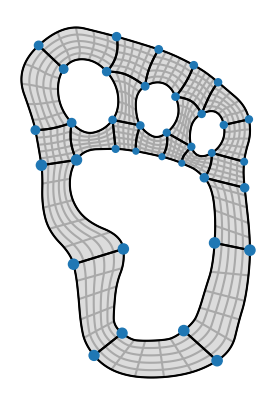

In [7]:
M.plotmesh(knots=1, nodes=30, color='gainsboro', patch_idx=False)#, color={0:3*(0.9,)})
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Yeti.pdf',bbox_inches='tight');

In [12]:
geos = geometry.mp_disk()

In [13]:
kvs = 5*[2*(bspline.make_knots(2,0,1,5),)]
M = topology.MultiPatch([(kv, g) for kv,g in zip(kvs,geometry.mp_disk())], autodetect=True)

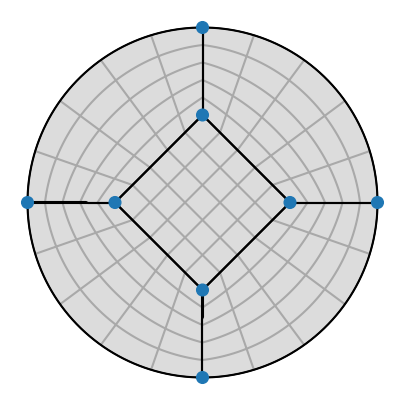

In [15]:
M.plotmesh(knots=1, nodes=50, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Circle.pdf',bbox_inches='tight');

In [37]:
geo1=geometry.circular_arc(np.pi, r=0.5)
geo2 = geometry.line_segment(1,2)
geo1 = geometry.outer_product(geo1,geo2)

geo2 = geo1.rotate_2d(np.pi)

In [38]:
kv = (bspline.make_knots(2,0,1,6),bspline.make_knots(2,0,1,3))
M = topology.MultiPatch([(kv, geo1),(kv,geo2)], autodetect=True)

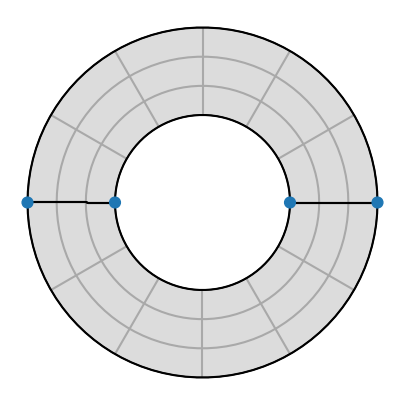

In [39]:
M.plotmesh(knots=1, nodes=30, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Anullus1.pdf',bbox_inches='tight');

In [41]:
geo1=geometry.circular_arc(2*np.pi, r=0.5)
geo2 = geometry.line_segment(1,2)
geo=geometry.outer_product(geo1,geo2)

In [42]:
kv = (bspline.make_knots(2,0,1,12),bspline.make_knots(2,0,1,3))
M = topology.MultiPatch([(kv, geo)], autodetect=True)

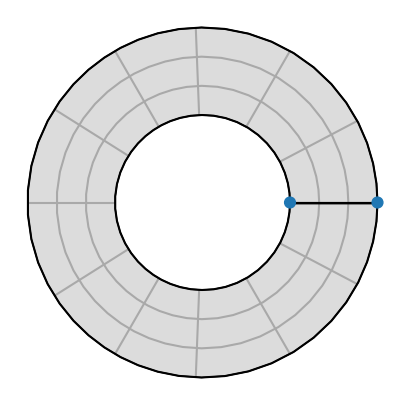

In [43]:
M.plotmesh(knots=1, nodes=120, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Anullus2.pdf',bbox_inches='tight');

In [24]:
f = lambda u,v,r1,r2,theta1,theta2: (
    (r1 + (r2-r1)*u) * np.cos(theta1 + (theta2-theta1)*v),
    (r1 + (r2-r1)*u) * np.sin(theta1 + (theta2-theta1)*v)
)

In [44]:
geo1 = geometry.UserFunction(lambda u,v: f(u,v,0.5,0.75,-np.pi/6,np.pi/2),((0,1),(0,1)))
geo2 = geometry.UserFunction(lambda u,v: f(u,v,0.5,0.75,np.pi/2,7*np.pi/6),((0,1),(0,1)))
geo3 = geometry.UserFunction(lambda u,v: f(u,v,0.5,0.75,7*np.pi/6,11*np.pi/6),((0,1),(0,1)))
geo4 = geometry.UserFunction(lambda u,v: f(u,v,0.75,1,np.pi/6,5*np.pi/6),((0,1),(0,1)))
geo5 = geometry.UserFunction(lambda u,v: f(u,v,0.75,1,5*np.pi/6,9*np.pi/6),((0,1),(0,1)))
geo6 = geometry.UserFunction(lambda u,v: f(u,v,0.75,1,3*np.pi/2,13*np.pi/6),((0,1),(0,1)))

In [45]:
geos=[geo1,geo2,geo3,geo4,geo5,geo6]

In [46]:
kv = (bspline.make_knots(2,0,1,8),bspline.make_knots(2,0,1,3))
M = topology.MultiPatch([(kv, geo) for geo in geos], autodetect=False)

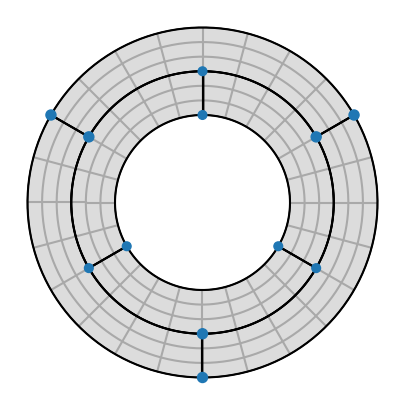

In [47]:
M.plotmesh(knots=1, nodes=30, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/ShiftedRing.pdf',bbox_inches='tight');

In [30]:
H = np.zeros(len(M.vertices))
for geo in M.geos:
    vtx = np.array([M.add_vertex(c) for c in topology.corners(geo, ravel = True)])
    diam = np.linalg.norm([b-a for a,b in geo.bounding_box(full=True)])
    H[vtx] = np.maximum(H[vtx],diam)
print(H)

[1.30504 1.30504 1.29904 1.29904 1.30504 1.30504 1.73656 1.73656 1.73656 1.73656 1.73205 1.73205]


In [439]:
X = np.array([1,2,3,4,5])

In [441]:
np.maximum(X,3)

array([3, 3, 3, 4, 5])

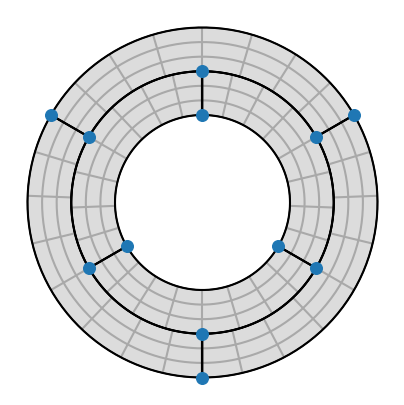

In [421]:
M.plotmesh(knots=1, nodes=70, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/ShiftedRing.pdf',bbox_inches='tight');

In [458]:
f = lambda r,theta: (r*np.cos(theta),r*np.sin(theta)) 

In [474]:
f = lambda r,theta: (r*np.cos(theta),r*np.sin(theta)) 
geo1 = geometry.UserFunction(f,((-np.pi/6,np.pi/2),(0.5,0.75)))
geo2 = geometry.UserFunction(f,((np.pi/2,7*np.pi/6),(0.5,0.75)))
geo3 = geometry.UserFunction(f,((7*np.pi/6,11*np.pi/6),(0.5,0.75)))
geo4 = geometry.UserFunction(f,((np.pi/6,5*np.pi/6),(0.75,1)))
geo5 = geometry.UserFunction(f,((5*np.pi/6,9*np.pi/6),(0.75,1)))
geo6 = geometry.UserFunction(f,((3*np.pi/2,13*np.pi/6),(0.75,1)))

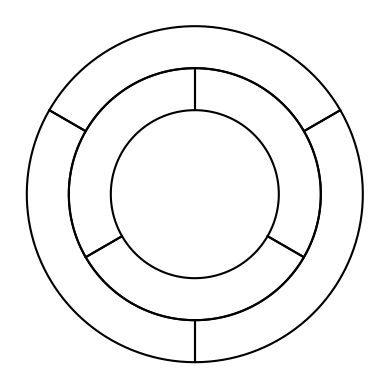

In [475]:
vis.plot_geo(geo1,grid=2)
vis.plot_geo(geo2,grid=2)
vis.plot_geo(geo3,grid=2)
vis.plot_geo(geo4,grid=2)
vis.plot_geo(geo5,grid=2)
vis.plot_geo(geo6,grid=2)
plt.axis('scaled');
plt.axis('off');

In [186]:
geo1=geometry.Quad(np.array([[0,0],[2,0],[0,1],[1,1]]).T).translate((-0.5,0.5))
geo2=geo1.rotate_2d(np.pi/2)
geo3=geo1.rotate_2d(np.pi)
geo4=geo1.rotate_2d(3*np.pi/2)
geo5=geometry.unit_square().translate((-0.5,-.5))
geos=[geo1,geo2,geo3,geo4,geo5]

In [187]:
kvs = 5*[(bspline.make_knots(2,0,1,5),bspline.make_knots(2,0,1,5))]# + [2*(bspline.make_knots(2,0,1,3),)]

In [188]:
M = topology.MultiPatch([(kv, g) for kv,g in zip(kvs,geos)], autodetect=False)

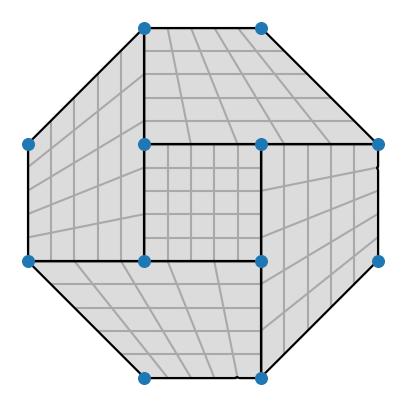

In [189]:
M.plotmesh(knots=1, nodes=70, color='gainsboro', patch_idx=False)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/Octagon.pdf',bbox_inches='tight');

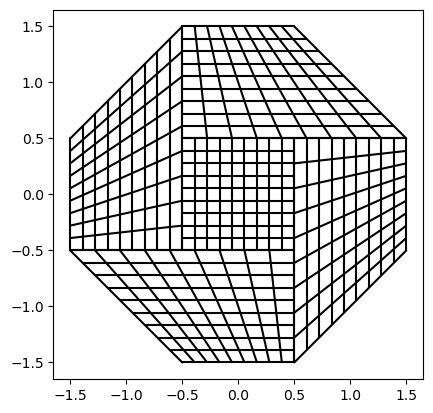

In [134]:
vis.plot_geo(geo1)
vis.plot_geo(geo2)
vis.plot_geo(geo3)
vis.plot_geo(geo4)
vis.plot_geo(geo5)
plt.axis('scaled');

In [76]:
MP.h_refine(h_ref={0:1,2:-1,4:1,9:-1,11:1,13:-1,15:1,17:-1,19:-1})

setting up constraints took 0.06725645065307617 seconds.
Basis setup took 0.0029823780059814453 seconds


In [6]:
MP.mesh.plotmesh(knots=True, nodes=0, color='white', patch_idx=True)
plt.axis('scaled');
plt.axis('off');

NameError: name 'MP' is not defined

In [78]:
Phi = MP.Basis

In [79]:
eigs = scipy.sparse.linalg.eigs(Phi.T@Phi)[0]

In [80]:
np.max(eigs)/min(eigs)

np.complex128(1.0000024494621094+0j)

In [81]:
np.max(eigs)

np.complex128(3.5991242941149806+0j)

In [82]:
np.min(eigs)

np.complex128(3.5991154782179895+0j)

In [21]:
kvs[0].numdofs

4